In [12]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.special import erf

Main function

In [2]:
from scipy.optimize import curve_fit # To use in Dunn Function

def Dunn(V, I, nus, Apply=True):
    """
    Implements the Dunn method to separate the capacitive and diffusional contributions
    in cyclic voltammetry (CV) measurements performed at different scan rates.

    The total current at each potential V is modeled as:
        i(V, ν) = k1 * ν + k2 * ν^(1/2)

    where:
        - k1 * ν  → capacitive contribution (surface storage)
        - k2 * ν^(1/2) → diffusional contribution (faradaic/diffusion processes)

    Parameters
    ----------
    V : list of np.ndarray
        List containing the arrays of potentials (V) measured at each scan rate.
    I : list of np.ndarray
        List containing the arrays of currents (A) corresponding to the potentials.
    nus : array-like
        List or array with the scan rates (V/s).
    Apply : bool, optional (default=True)
        If True, applies limits to the fit to avoid non-physical results.

    Returns
    -------
    Icap : np.ndarray
        Capacitive current (k1 * ν) for each potential.
    Ifar : np.ndarray
        Diffusional current (k2 * ν^(1/2)) for each potential.
    eIcap : np.ndarray
        Standard deviation of the capacitive current.
    eIfar : np.ndarray
        Standard deviation of the diffusional current.

    Reference:
        Dunn, B. et al. Science, 2011, 334, 968–971.
    """

    # Define the linear function to be fitted: y = a*x + b
    # In the context, x = ν^(1/2) and y = i(V,ν)/ν^(1/2)
    def F(x, a, b):
        return a * x + b

    # Inicializa listas para armazenar resultados e erros
    Icap = []   # Capacitive current
    eIcap = []  # Error associated with the capacitive current
    Ifar = []   # Diffusional current
    eIfar = []  # Error associated with the diffusional current

    # Loop over each potential (column of the arrays)
    for i in range(len(V[0])):

        # Calculate the vector of ν^(1/2)
        k = np.array(nus)**(1/2)

        # For each fixed potential, construct vector with i(V,ν)/ν^(1/2)
        Iv = np.array([I[j][i] / k[j] for j in range(len(V))])

        # Extract the current values near the analyzed potential
        # to define intervals of plausibility for the fit
        Iinterval = []
        for j in range(len(V)):
            Iinterval.extend(I[j][V[j] == V[j][i]])

        # Define the safety factor (fraction) used in the fit limits
        frac = 0.8

        # Lower and upper bounds for the fit parameters
        lower_bounds = [
            frac * min(Iinterval) / nus[-1],
            frac * min(Iinterval) / k[-1]
        ]
        upper_bounds = [
            frac * max(Iinterval) / nus[-1],
            frac * max(Iinterval) / k[-1]
        ]

        # Linear fit with bounds (if Apply=True)
        # The fit returns the parameters popt = [k1, k2]
        if upper_bounds[0] != lower_bounds[0] and Apply:
            popt, pcov = curve_fit(F, k, Iv, bounds=(lower_bounds, upper_bounds))
        else:
            # Otherwise, perform an unconstrained fit
            popt, pcov = curve_fit(F, k, Iv)

        # Calculate the standard deviations (errors) of the fitted parameters
        std = np.sqrt(np.diag(pcov))

        # Rebuild the current components using the fitted parameters:
        # Icap = k1 * ν  → capacitiva
        # Ifar = k2 * ν^(1/2) → difusional
        Ifar.append(popt[1] * k)
        Icap.append(popt[0] * nus)

        # Calculate the errors associated with each component
        eIfar.append(std[0] * k)
        eIcap.append(std[1] * nus)

    # Convert the lists to arrays and transpose for organization [ν, V]
    Icap = np.transpose(np.array(Icap))
    Ifar = np.transpose(np.array(Ifar))
    eIfar = np.transpose(np.array(eIfar))
    eIcap = np.transpose(np.array(eIcap))

    return Icap, Ifar, eIfar, eIcap

In [61]:
from scipy.optimize import curve_fit # To use in Dunn Function

def Dunn(V, I, nus, Apply=True):
    """
    Implements the Dunn method to separate the capacitive and diffusional contributions
    in cyclic voltammetry (CV) measurements performed at different scan rates.

    The total current at each potential V is modeled as:
        i(V, ν) = k1 * ν + k2 * ν^(1/2)

    where:
        - k1 * ν  → capacitive contribution (surface storage)
        - k2 * ν^(1/2) → diffusional contribution (faradaic/diffusion processes)

    Parameters
    ----------
    V : list of np.ndarray
        List containing the arrays of potentials (V) measured at each scan rate.
    I : list of np.ndarray
        List containing the arrays of currents (A) corresponding to the potentials.
    nus : array-like
        List or array with the scan rates (V/s).
    Apply : bool, optional (default=True)
        If True, applies limits to the fit to avoid non-physical results.

    Returns
    -------
    Icap : np.ndarray
        Capacitive current (k1 * ν) for each potential.
    Ifar : np.ndarray
        Diffusional current (k2 * ν^(1/2)) for each potential.
    eIcap : np.ndarray
        Standard deviation of the capacitive current.
    eIfar : np.ndarray
        Standard deviation of the diffusional current.

    Reference:
        Dunn, B. et al. Science, 2011, 334, 968–971.
    """

    nus   = np.asarray(nus, dtype=float)
    sqrt_nus = np.sqrt(nus)
    n_rates = len(nus)

    # --- 1. Convert to arrays and flatten ---------------------------------
    V = [np.asarray(v, dtype=float).ravel() for v in V]
    I = [np.asarray(cur, dtype=float).ravel() for cur in I]

    # --- 2. Align all CVs to a common potential grid --------------------
    # If the potential arrays are already identical, keep them.
    # Otherwise interpolate each CV onto a common grid using normalized
    # cycle progress (0 → start, 1 → end).  This preserves the forward/
    # reverse structure without mixing the two branches.
    lengths = [len(v) for v in V]
    identical = (len(set(lengths)) == 1 and
                 all(np.allclose(v, V[0], atol=1e-6) for v in V))

    if identical:
        V_common = V[0]
        I_aligned = np.vstack(I)                 # shape (n_rates, n_points)
    else:
        n_points = max(lengths)
        V_aligned = np.zeros((n_rates, n_points))
        I_aligned = np.zeros((n_rates, n_points))

        for j in range(n_rates):
            n = len(V[j])
            s_old = np.linspace(0, 1, n)
            s_new = np.linspace(0, 1, n_points)
            V_aligned[j, :] = np.interp(s_new, s_old, V[j])
            I_aligned[j, :] = np.interp(s_new, s_old, I[j])

        V_common = np.mean(V_aligned, axis=0)    # ≈ potential at each index
        # (I_aligned is already the aligned currents)

    n_points = len(V_common)

    # --- 3. Dunn analysis at each common potential -----------------------
    Icap, Ifar, eIcap, eIfar = [], [], [], []

    def F(x, a, b):
        return a * x + b

    for i in range(n_points):
        # y = i(V,ν)/√ν   vs   x = √ν
        y = I_aligned[:, i] / sqrt_nus

        # If every current is essentially zero, skip the fit
        if np.max(np.abs(y)) < 1e-15:
            z = np.zeros(n_rates)
            Icap.append(z); Ifar.append(z)
            eIcap.append(z); eIfar.append(z)
            continue

        if Apply:
            # Bounds based on the largest absolute current at this potential
            i_max = np.max(np.abs(I_aligned[:, i]))
            bound = 10.0 * i_max / np.min(sqrt_nus)

            try:
                popt, pcov = curve_fit(
                    F, sqrt_nus, y, p0=[0, 0],
                    bounds=([-bound, -bound], [bound, bound]),
                    maxfev=10000
                )
                std = np.sqrt(np.diag(pcov))
            except RuntimeError:
                # Fallback to ordinary least squares
                X = np.column_stack([sqrt_nus, np.ones(n_rates)])
                popt, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
                popt = np.array(popt)
                std  = np.array([0.0, 0.0])
        else:
            X = np.column_stack([sqrt_nus, np.ones(n_rates)])
            popt, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            popt = np.array(popt)
            std  = np.array([0.0, 0.0])

        k1, k2 = popt[0], popt[1]

        # Reconstruct separated currents
        Icap.append(k1 * nus)          # capacitive   = k1·ν
        Ifar.append(k2 * sqrt_nus)    # faradaic     = k2·√ν

        # Error propagation (FIXED: std[0] ↔ k1, std[1] ↔ k2)
        eIcap.append(std[0] * nus)
        eIfar.append(std[1] * sqrt_nus)

    # Transpose to shape (n_scan_rates, n_potentials)
    Icap  = np.array(Icap).T
    Ifar  = np.array(Ifar).T
    eIcap = np.array(eIcap).T
    eIfar = np.array(eIfar).T

    return Icap, Ifar, eIfar, eIcap, V_common

Let's import the ideal data to make the adjust

In [62]:
nus = np.array([10,20,30,40,50])
Et = []
It = []

# We have a 1 cycle data at different scan rates,
# so we read each file and store the potentials and currents in lists
for i in range(len(nus)):
    data = pd.read_csv(f'Data/VC_{nus[i]}mVps.txt', sep=';')
    Et.append(data['Potential (V)'].values)
    It.append(data['Current (A)'].values)

In [70]:
# Calculate the capacitive and diffusional contributions using the Dunn method
Icap, Ifar,eIfar,eIcap,Et_ = Dunn( np.array(Et) , np.array(It),nus,True )

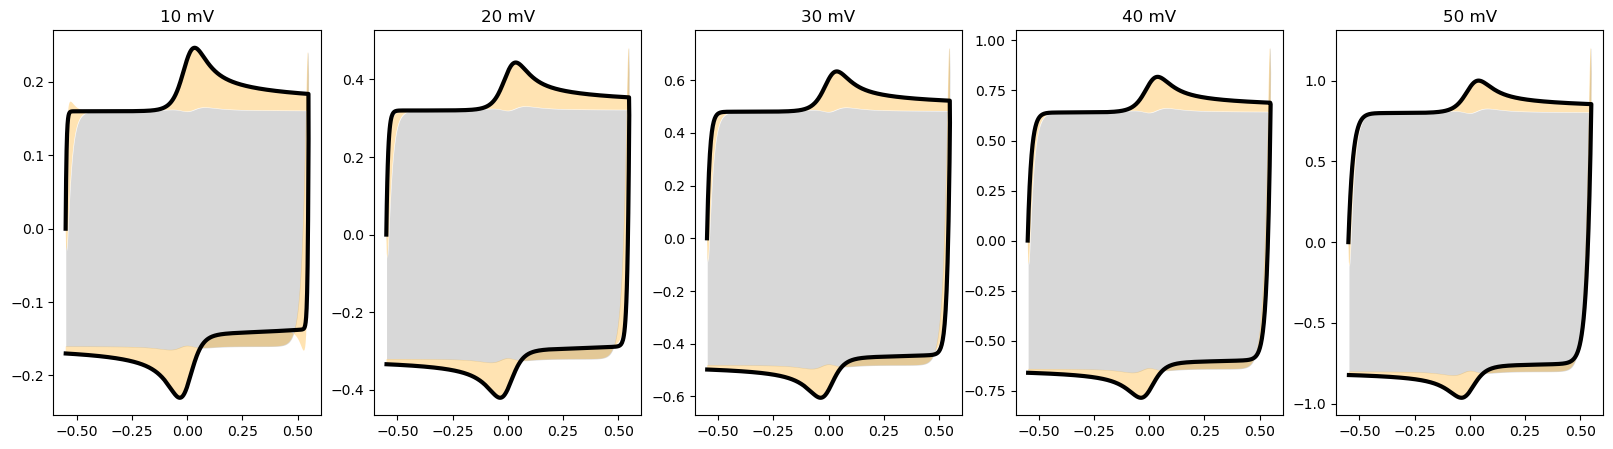

In [71]:
# Show the data obtained
fig = plt.figure(figsize=(20,5))

gs = GridSpec(1,len(nus),fig)


for i in range(len(nus)):
    ax1 = fig.add_subplot(gs[i])

    ax1.plot(Et[i],It[i],color='black',lw=3)
    
    ax1.fill_between(Et[i], Icap[i]  , color = 'gray',alpha=0.3,linewidth = 0)
    ax1.fill_between(
    Et[i], 
    Icap[i],                          # Bottom Limit 
    Icap[i] + Ifar[i],               # Top Limit
    where=(Ifar[i] >= 0),             
    color='orange', 
    alpha=0.3, 
    linewidth=0
    )
  

    ax1.fill_between(
    Et[i],
    Icap[i],                          # Bottom Limit
    Icap[i] + Ifar[i],               # Top Limit
    where=(Ifar[i] <= 0),             # 
    color='orange', 
    alpha=0.3, 
    linewidth=0
    )
    
    ax1.set_title(f'{nus[i]} mV')

    

Now let's compare each of them to the ideal data

In [72]:
Eti = []
Ici = []
Ifi = []
# We have a 1 cycle data at different scan rates,
# so we read each file and store the potentials and currents in lists
for i in range(len(nus)):
    data = pd.read_csv(f'Data/ideal/VC_{nus[i]}mVps.txt', sep=';')
    Eti.append(data['Potential (V)'].values)
    Ici.append(data['ic (A)'].values)
    Ifi.append(data['if (A) '].values)

Comparing them

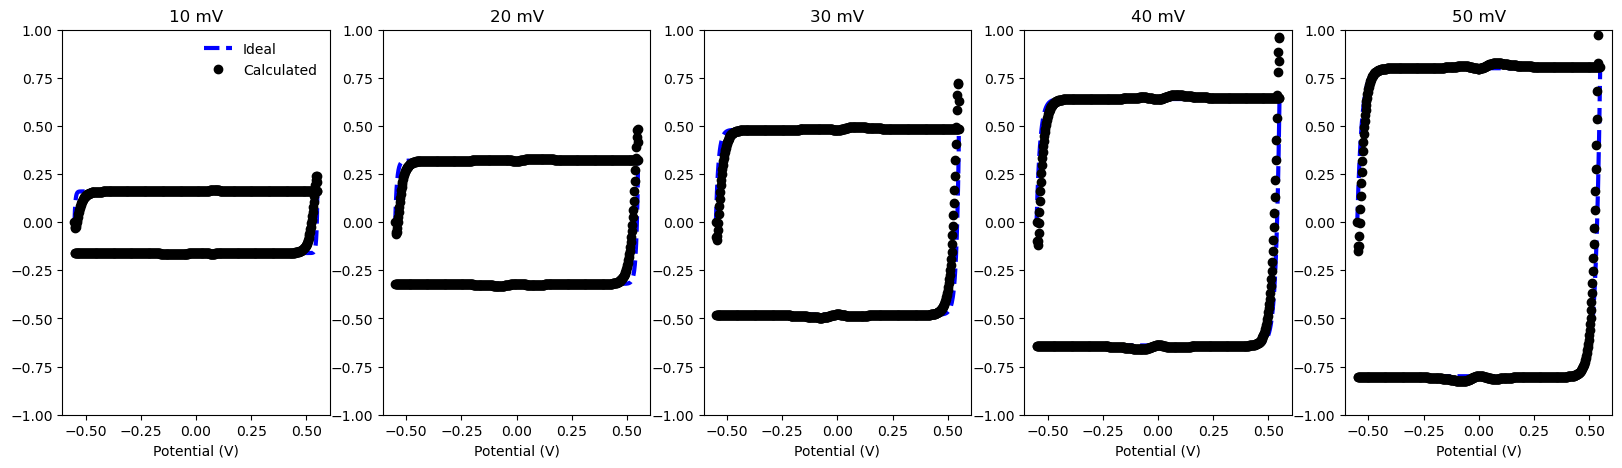

In [73]:
fig = plt.figure(figsize=(20,5))

gs = GridSpec(1,len(nus),fig)


for i in range(len(nus)):
    ax1 = fig.add_subplot(gs[i])

    ax1.plot(Eti[i],Ici[i],'--',color='blue',label = 'Ideal',lw=3)
    ax1.plot(Et[i],Icap[i],'o',color='black',label = 'Calculated')
    if i ==0:
        ax1.legend(frameon = False)
    ax1.set_ylim(-1,1)
    ax1.set_title(f'{nus[i]} mV')
    ax1.set_xlabel('Potential (V)')

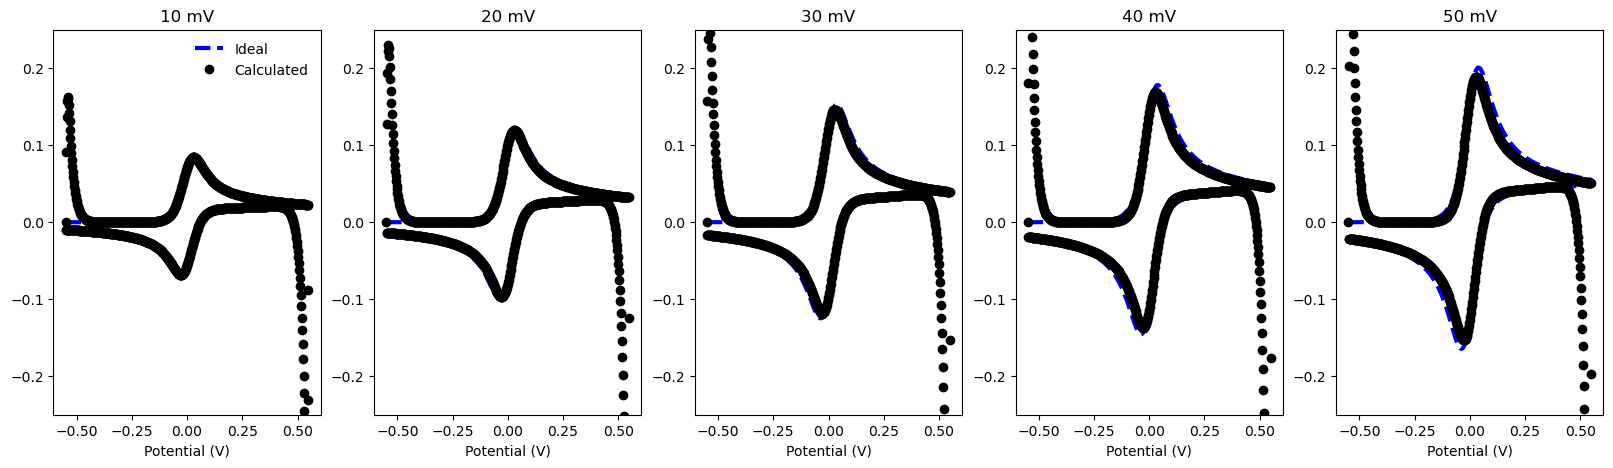

In [74]:
fig = plt.figure(figsize=(20,5))

gs = GridSpec(1,len(nus),fig)


for i in range(len(nus)):
    ax1 = fig.add_subplot(gs[i])

    ax1.plot(Eti[i],Ifi[i],'--',color='blue',label = 'Ideal',lw=3)
    ax1.plot(Et[i],Ifar[i],'o',color='black',label = 'Calculated')

    
    if i ==0:
        ax1.legend(frameon = False)
    ax1.set_ylim(-0.25,0.25)    
    ax1.set_title(f'{nus[i]} mV')
    ax1.set_xlabel('Potential (V)')

Make a plot for article

In [75]:
def Green_Area(x, y):
    """
    Calculate the area of a closed polygon using Green's theorem
    A = 1/2 * |sum(x_i * y_{i+1} - x_{i+1} * y_i)|
    """
    # Ensure the polygon is closed (first point = last point)
    if not (np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1])):
        x = np.append(x, x[0])
        y = np.append(y, y[0])
    
    # Apply Green's theorem
    area = 0.5 * np.abs(np.sum(x[:-1] * y[1:] - x[1:] * y[:-1]))
    return area

In [77]:
# Now calculate each element area
ACap = np.array([Green_Area(Et[l],Icap[l]) for l in range(len(nus))])
Afar = np.array([Green_Area(Et[l],Ifar[l]) for l in range(len(nus))])
Asum = ACap + Afar

(0.0, 120.0)

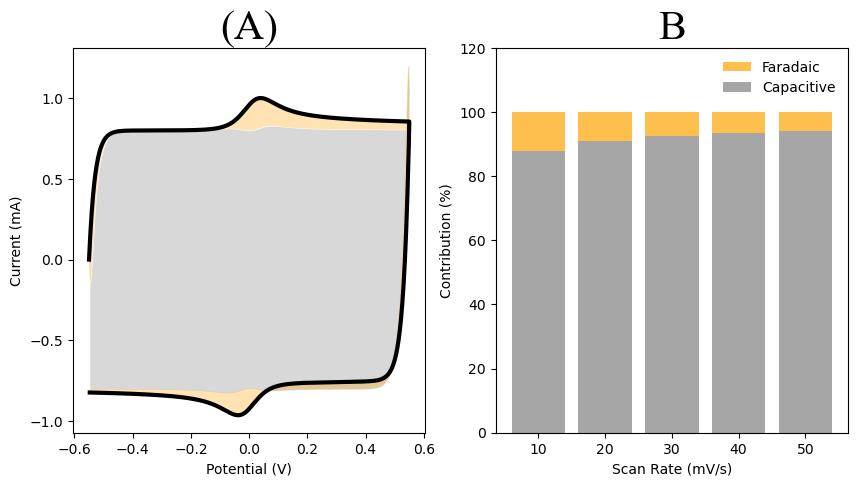

In [79]:
fig = plt.figure(figsize = (10, 5))
# Criar 2 linhas e 3 colunas
gs = GridSpec(1, 2)


u = -1
ax1 = fig.add_subplot(gs[0])

ax1.plot(Et[u],It[u],color='black',lw=3)

ax1.fill_between(Et[u], Icap[i]  , color = 'gray',alpha=0.3,linewidth = 0)
ax1.fill_between(
Et[u], 
Icap[u],                          # Limite inferior (Parte de cima de onde tem parte capacitiva)
Icap[u] + Ifar[u],               # Parte de Cima, somando parte faradaica a capacitiva
where=(Ifar[u] >= 0),             # Só preencher parte de cima
color='orange', 
alpha=0.3, 
linewidth=0
)
# Mesmo de antes, mas para parte de baixo do gráfico
ax1.fill_between(
Et[u], 
Icap[u],                          # 
Icap[u] + Ifar[u],               # 
where=(Ifar[u] <= 0),             # 
color='orange', 
alpha=0.3, 
linewidth=0
)

ax1.set_ylabel('Current (mA)')
ax1.set_xlabel('Potential (V)')
ax1.set_title(f'(A)',fontname = 'Times New Roman',fontsize = 30)


# Segunda linha - gráficos de barras empilhadas
ax2 = fig.add_subplot(gs[1])

# Calcular as porcentagens
porc_Cap = (ACap / Asum) * 100
porc_far = (Afar / Asum) * 100

# Número de velocidades de varredura
n_velocidades = len(nus)
x_pos = np.arange(n_velocidades)

# Plotar gráficos de barras empilhadas

ax2.bar(x_pos, porc_far, bottom=porc_Cap, label='Faradaic', color='orange', alpha=0.7)
ax2.bar(x_pos, porc_Cap, label='Capacitive', color='gray', alpha=0.7)

# Configurar os eixos dos gráficos de barras
letras = ['(D)','(E)','(F)']
h = 0

ax2.set_xlabel('Scan Rate (mV/s)')
ax2.set_ylabel('Contribution (%)')
ax2.set_title(f'B',fontname = 'Times New Roman',fontsize = 30)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{nus[i]}' for i in range(n_velocidades)])
ax2.legend(frameon=False)
ax2.set_ylim(0, 120)
